<a href="https://colab.research.google.com/github/Rahulnema04/cifar10-from-scratch/blob/main/phase2_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),        # flip image left-right randomly
    transforms.RandomCrop(32, padding=4),     # shift image slightly in any direction
    transforms.ToTensor(),
    transforms.Normalize(                     # per-channel mean and std of CIFAR-10
        mean=(0.4914, 0.4822, 0.4465),
        std =(0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std =(0.2470, 0.2435, 0.2616)
    )
])

train_data = datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_transform)
test_data  = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=256, shuffle=False, num_workers=2)

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

100%|██████████| 170M/170M [00:01<00:00, 101MB/s]


Train batches: 391 | Test batches: 40


In [ ]:
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # ── Conv Block 1 ──────────────────────────────────────────
        # in:  (B, 3,  32, 32)
        # out: (B, 32, 16, 16)  after maxpool
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3,  out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)   # halves spatial dims
        )

        # ── Conv Block 2 ──────────────────────────────────────────
        # in:  (B, 32, 16, 16)
        # out: (B, 64, 8,  8)   after maxpool
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # ── Conv Block 3 ──────────────────────────────────────────
        # in:  (B, 64, 8, 8)
        # out: (B, 128, 4, 4)   after maxpool
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # ── Classifier head ───────────────────────────────────────
        # after block3: (B, 128, 4, 4) → flatten → (B, 2048)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),               # you'll study this in Phase 3
            nn.Linear(256, 10)               # 10 class scores (logits)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x                             # raw logits — loss fn applies softmax internally

In [ ]:
# Input:   RF = 1   (each pixel sees itself)
#
# Block 1 — Conv2d(kernel=3, padding=1, stride=1):
#   RF = 1 + (3-1) × 1 = 3
# Block 1 — MaxPool(kernel=2, stride=2):
#   RF = 3 + (2-1) × 1 = 4   (stride now accumulates to 2)
#
# Block 2 — Conv2d(kernel=3, padding=1, stride=1):
#   RF = 4 + (3-1) × 2 = 8
# Block 2 — MaxPool(kernel=2, stride=2):
#   RF = 8 + (2-1) × 2 = 10   (stride accumulates to 4)
#
# Block 3 — Conv2d(kernel=3, padding=1, stride=1):
#   RF = 10 + (3-1) × 4 = 18
# Block 3 — MaxPool(kernel=2, stride=2):
#   RF = 18 + (2-1) × 4 = 22  (stride accumulates to 8)
#
# Final receptive field = 22×22 pixels out of a 32×32 image
# Each neuron in the final feature map sees a 22×22 patch of the input
# That's why deeper = more context per neuron

model = CIFAR10_CNN()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

CIFAR10_CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_fe

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")    # should say cuda on Colab with GPU enabled

model     = CIFAR10_CNN().to(device)
criterion = nn.CrossEntropyLoss()               # softmax + NLL loss combined
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Using: cpu


In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()           # clear gradients from last step
        outputs = model(images)         # forward pass
        loss = criterion(outputs, labels)
        loss.backward()                 # backward pass — PyTorch handles this now
        optimizer.step()                # update weights

        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()

    acc = correct / len(loader.dataset)
    return total_loss / len(loader), acc


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():               # no gradients needed for evaluation
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()

    acc = correct / len(loader.dataset)
    return total_loss / len(loader), acc

In [ ]:
epochs = 20
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    vl_loss, vl_acc = eval_epoch(model,  test_loader,  criterion, device)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f"Epoch {epoch:2d} | "
          f"Train loss: {tr_loss:.3f}  acc: {tr_acc:.3f} | "
          f"Val loss: {vl_loss:.3f}  acc: {vl_acc:.3f}")

Epoch  1 | Train loss: 1.578  acc: 0.418 | Val loss: 1.175  acc: 0.580
Epoch  2 | Train loss: 1.253  acc: 0.550 | Val loss: 1.090  acc: 0.612
Epoch  3 | Train loss: 1.130  acc: 0.598 | Val loss: 0.892  acc: 0.677
Epoch  4 | Train loss: 1.035  acc: 0.635 | Val loss: 0.842  acc: 0.693
Epoch  5 | Train loss: 0.989  acc: 0.652 | Val loss: 0.799  acc: 0.721
Epoch  6 | Train loss: 0.942  acc: 0.671 | Val loss: 0.789  acc: 0.717
Epoch  7 | Train loss: 0.905  acc: 0.685 | Val loss: 0.788  acc: 0.720
Epoch  8 | Train loss: 0.875  acc: 0.695 | Val loss: 0.733  acc: 0.741
Epoch  9 | Train loss: 0.847  acc: 0.709 | Val loss: 0.700  acc: 0.755
Epoch 10 | Train loss: 0.822  acc: 0.715 | Val loss: 0.705  acc: 0.753
Epoch 11 | Train loss: 0.801  acc: 0.724 | Val loss: 0.642  acc: 0.776
Epoch 12 | Train loss: 0.774  acc: 0.732 | Val loss: 0.681  acc: 0.757
Epoch 13 | Train loss: 0.755  acc: 0.740 | Val loss: 0.671  acc: 0.767
Epoch 14 | Train loss: 0.737  acc: 0.748 | Val loss: 0.612  acc: 0.784
Epoch 

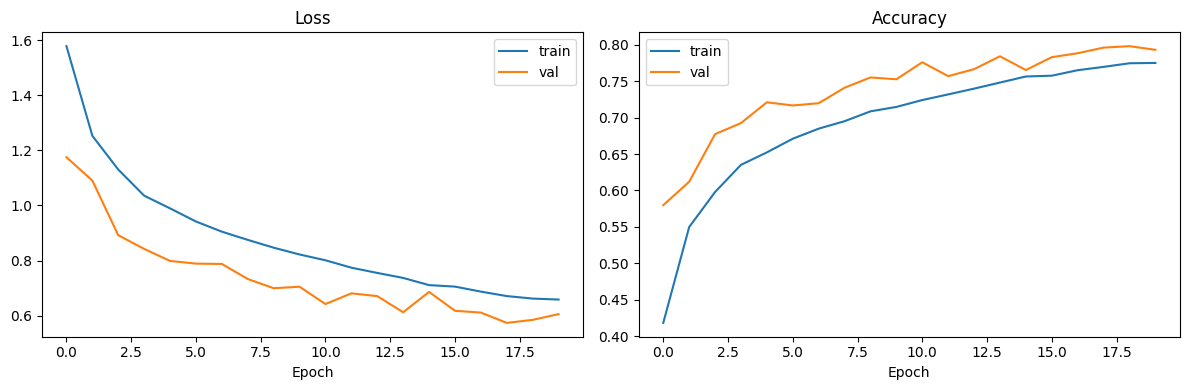

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='train')
ax1.plot(history['val_loss'],   label='val')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history['train_acc'], label='train')
ax2.plot(history['val_acc'],   label='val')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()